In [1]:
%matplotlib ipympl

import sys
import os
sys.path.append("../../github_repos/nist_cdsaxs/src/")
import matplotlib.pyplot as plt

import importlib
import cdsaxs
import cdsaxs.loaders
import cdsaxs.loaders.load_data as loaders
import cdsaxs.plotting
import numpy as np

# if you are not actively developing the code, you can comment the rest of these out
# importlib.reload(cdsaxs)
# importlib.reload(cdsaxs.tools)
# importlib.reload(cdsaxs.calculators)
# importlib.reload(cdsaxs.data.data1d)
# importlib.reload(cdsaxs.data.data2d)
# importlib.reload(cdsaxs.data.dataset)
# importlib.reload(cdsaxs.loaders)
# importlib.reload(cdsaxs.data.metadata)
# importlib.reload(cdsaxs.plotting)
# importlib.reload(cdsaxs.plotting.plotting)
# importlib.reload(cdsaxs.plotting._plotting_tools)
# # importlib.reload(cdsaxs.plotting._plotly_tools)
# importlib.reload(cdsaxs.reduction)
# importlib.reload(cdsaxs.data.data2d)

# from cdsaxs.plotting import _plotly_tools as plotly_tools
from cdsaxs.plotting import _plotting_tools as plotting_tools
from cdsaxs.plotting import plotting as cdsaxs_plotting

# cvs_path = os.path.abspath("data_W204_F2/W204_metadata.csv")
# dataset = loaders.LoadDataset_MetadataCSV("test", metadata_csv_filepath=cvs_path, data_name_pattern="{sample_phi_deg}", detector_type='pilatus')
# dataset.update_all_metadata({'center_px': (740, 490), 'sample_phi_offset_deg': -2})

# data = dataset.datas["0.0"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import inspect
import matplotlib

In [3]:
from cdsaxs.loaders.load_data import filter_filenames

In [4]:
# set the data directory
data_dir = "./SRM_i10/"

# filter to just the files you want to load in the current dataset
filenames_als_300 = filter_filenames(directory_path=data_dir, filter_substrings=[['300ev', ('not', 'align'), ('not', 'lineup')]])


In [5]:
from cdsaxs.loaders import load_data

## Load Dataset

In [6]:
# a lot of the metadata is available in the file header
# change 'data_name_pattern' if you want to have different dictionary keys for dataset.datas
dataset = load_data.LoadDataset(dataset_name="als srm test", directory_path=data_dir, filenames=filenames_als_300, data_name_pattern="Sample Phi: {sample_phi_deg} Detector Theta: {detector_phi_deg}", beamline='als 11.0.1.2')


Loading files: 100%|█████████████████████████| 321/321 [00:09<00:00, 33.73it/s]

The following metadata is missing to calculate the beam coordinate scattering vector: ['sdd_cm', 'center_px', 'detector_phi0_deg', 'detector_phi_scale', 'detector_y0_mm']. Therefore, the sample coordinatescattering vector also could not be calculated
The following metadata is missing to calculate the beam coordinate scattering vector: ['sample_phi_offset_deg', 'sample_omega_deg', 'sample_omega_offset_deg', 'sample_chi_deg', 'sample_chi_offset_deg']. Therefore, the sample coordinatescattering vector also could not be calculated
No data type known for center_px.
Insufficient metadata to calculate q. Check your metadata to ensure the correct center position, wavelength, sample to detector distance, and pixel size are provided.
Created dataset from data directory: C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\SRM_i10


In [7]:
np.max(list(set([data.metadata["sample_phi_deg"] for data in dataset.datas.values()])))

np.float64(70.0)

In [8]:
np.min(list(set([data.metadata["sample_phi_deg"] for data in dataset.datas.values()])))

np.float64(-60.0)

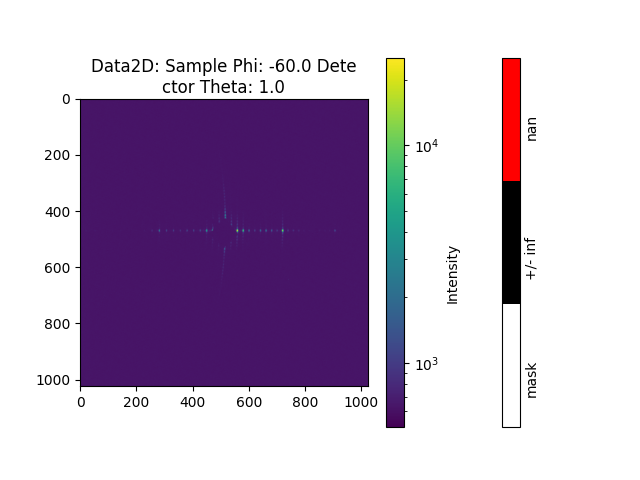

In [9]:
fig = dataset.datas["Sample Phi: -60.0 Detector Theta: 1.0"].plot_data()

In [11]:
dataset.datas.keys()

In [12]:
# list(set([data.metadata['detector_phi_deg'] for data in dataset.datas.values()]))

In [13]:
data = dataset.datas['Sample Phi: 0.0 Detector Theta: 1.0']
data.metadata

{'energy_ev': 300.011826472274,
 'wavelength_nm': 4.132643902047247,
 'sample_phi_deg': 0.0,
 'I0': -0.00326496367809065,
 'exposure_time_s': 0.0007500000130385199,
 'beam_current': 499.98775,
 'detector_phi_deg': 1.0,
 'detector_y_mm': 98.0,
 'pixel_size_um': 27.0,
 'data_directory': 'C:\\Users\\cmw5\\Documents\\beamtime_data\\20251112_ALS\\SRM_i10',
 'filename': 'jk_srm_i10_300ev_cdsaxs87449-00061.fits',
 'sample_phi_offset_deg': 0.0,
 'sample_chi_deg': 0.0,
 'sample_chi_offset_deg': 0.0,
 'sample_omega_deg': 0.0,
 'sample_omega_offset_deg': 0.0,
 'detector_phi0_deg': 0.0,
 'detector_phi_scale': 1.0,
 'detector_y0_mm': 0.0,
 'center_px': (0, 0)}

In [14]:
# set detector_phi0_deg and detector_y0_mm to indicate where the detector is at normal incidence
# detector_phi_scale is used as detector_phi_scale*(detector_y_mm - detector_y0_mm) to apply the appropriate correction after detector rotation/translation
dataset.update_all_metadata({'detector_phi0_deg': 1, 'detector_y0_mm': 98, "substrate_attenuation_coeff_um-1": 1/0.141555, "substrate_thickness_um": 100/1000, 'detector_phi_scale':0.985})

Updating datas:   0%|                                  | 0/312 [00:00<?, ?it/s]C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:451: UserWarning: The following metadata is missing to calculate the beam coordinate scattering vector: ['sdd_cm']. Therefore, the sample coordinatescattering vector also could not be calculated
  warnings.warn(f"{e}")
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:457: UserWarning: The beam-based scattering vectors qb are notcalculated and so sample-based scattering vectorsqs could not be calculated.
  warnings.warn(f"{e}")
Updating datas: 100%|█████████████████████| 312/312 [00:00<00:00, 34631.56it/s]


In [15]:
# dataset.apply_substrate_absorption_correction()
dataset.normalize_all_data_by_metadata(["exposure_time_s"])

C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\metadata.py:89: UserWarning: No data type known for center_px.
  warnings.warn(


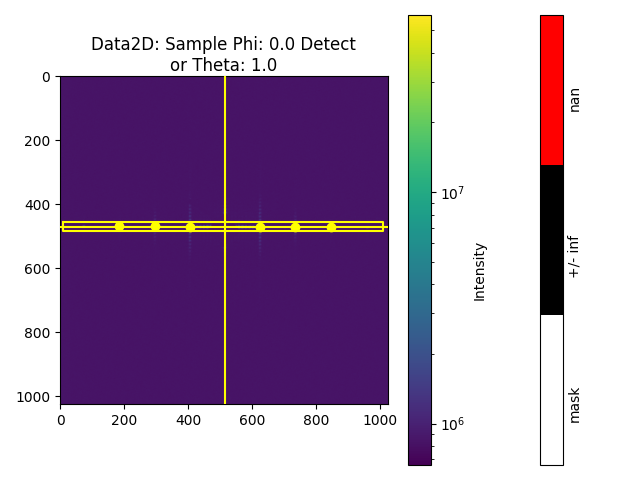

In [16]:
data = dataset.datas['Sample Phi: 0.0 Detector Theta: 1.0']
center, fig = data.find_beam_center_from_peaks(30, 1000, beam_center_guess=(470, 511), threshold_abs=4, min_distance=100, refinement_size=20, zoom_plot=False)

In [17]:
center

(470.33, 515.19)

In [18]:
dataset.update_all_metadata({'center_px': center, 'pixel_size_um': 27})

Updating datas:   0%|                                  | 0/312 [00:00<?, ?it/s]C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\metadata.py:89: UserWarning: No data type known for center_px.
  warnings.warn(
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:451: UserWarning: The following metadata is missing to calculate the beam coordinate scattering vector: ['sdd_cm']. Therefore, the sample coordinatescattering vector also could not be calculated
  warnings.warn(f"{e}")
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:457: UserWarning: The beam-based scattering vectors qb are notcalculated and so sample-based scattering vectorsqs could not be calculated.
  warnings.warn(f"{e}")
Updating datas: 100%|█████████████████████| 312/312 [00:00<00:00, 62321.31it/s]


In [19]:
data_keys = [key for key, value in dataset.datas.items() if np.abs(value.metadata['sample_phi_deg']) <= 5 and value.metadata['detector_phi_deg'] == 1 and value.metadata["sample_phi_deg"] not in (-2, 2)] # outlier in -2, look into this
data_keys

['Sample Phi: -3.0 Detector Theta: 1.0',
 'Sample Phi: -5.0 Detector Theta: 1.0',
 'Sample Phi: 4.0 Detector Theta: 1.0',
 'Sample Phi: 5.0 Detector Theta: 1.0',
 'Sample Phi: -4.0 Detector Theta: 1.0',
 'Sample Phi: -1.0 Detector Theta: 1.0',
 'Sample Phi: 1.0 Detector Theta: 1.0',
 'Sample Phi: 3.0 Detector Theta: 1.0',
 'Sample Phi: 0.0 Detector Theta: 1.0']

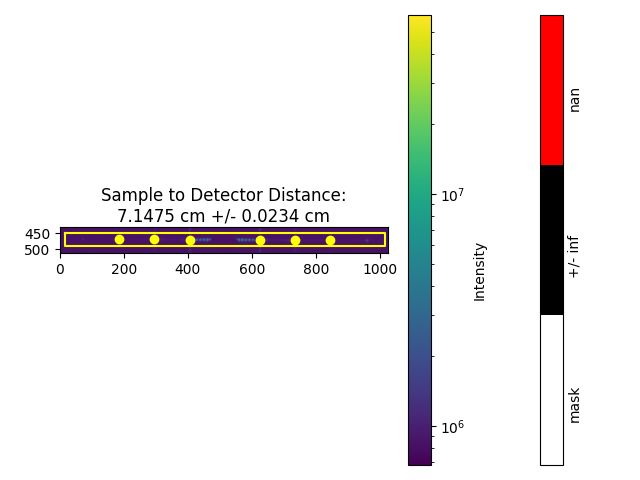

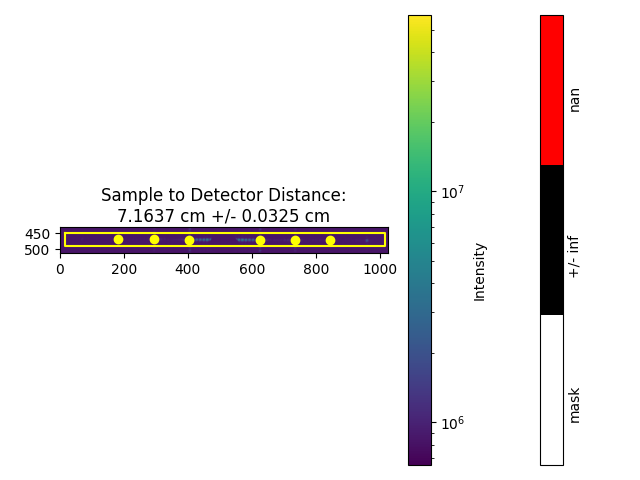

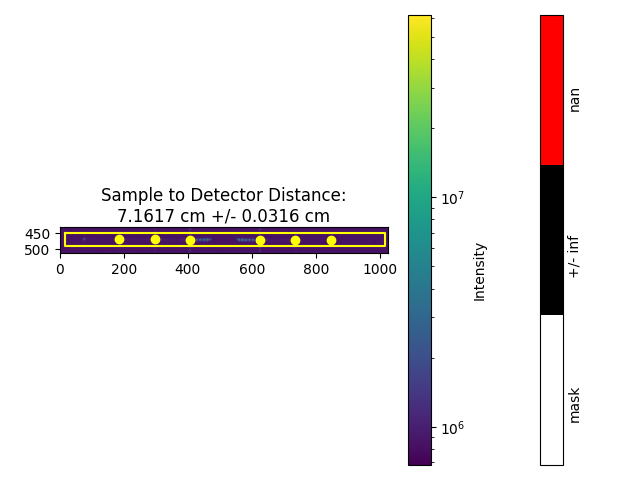

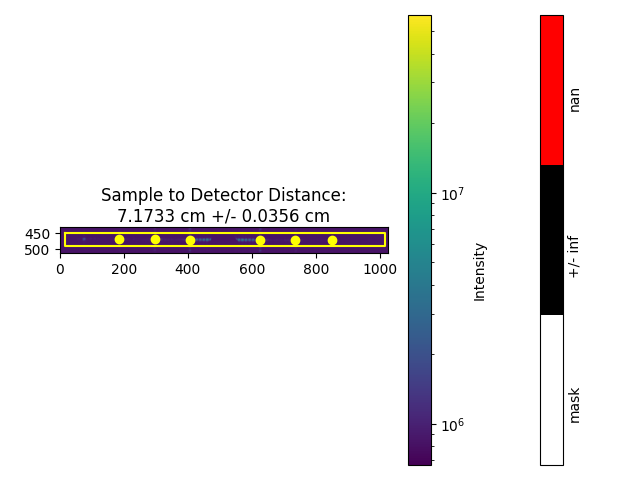

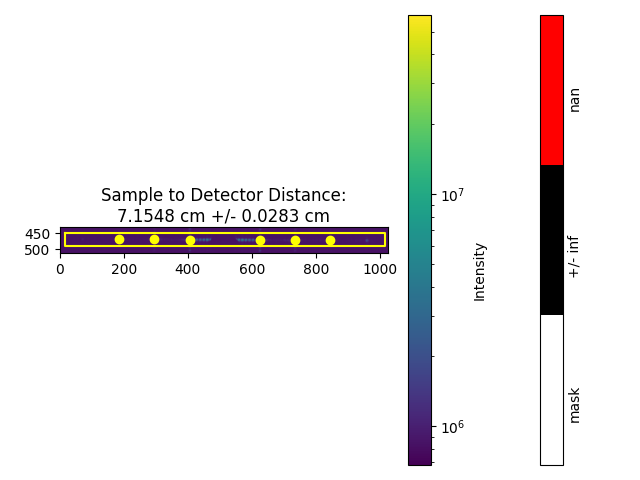

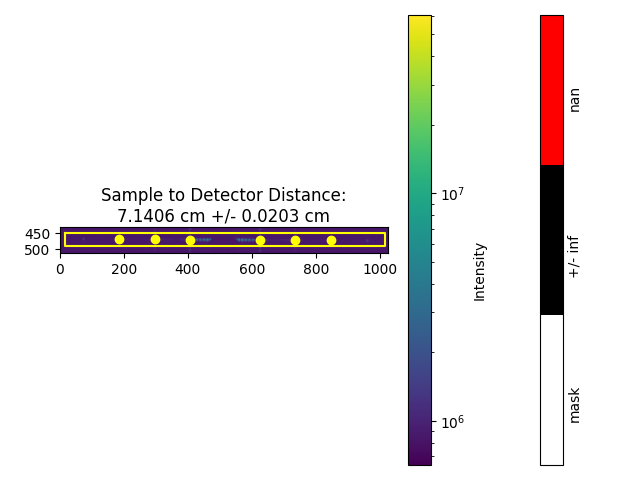

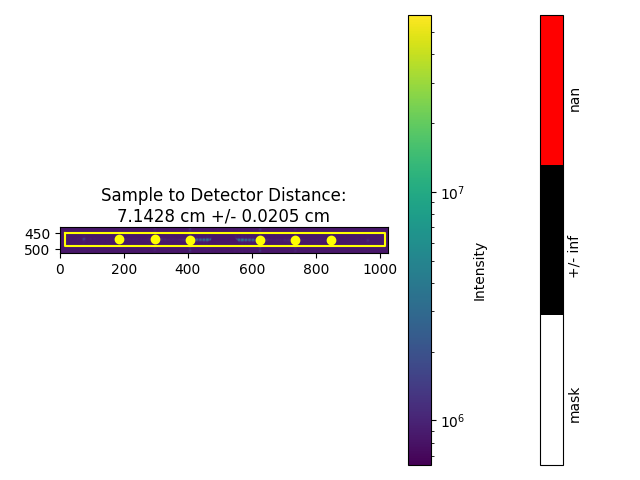

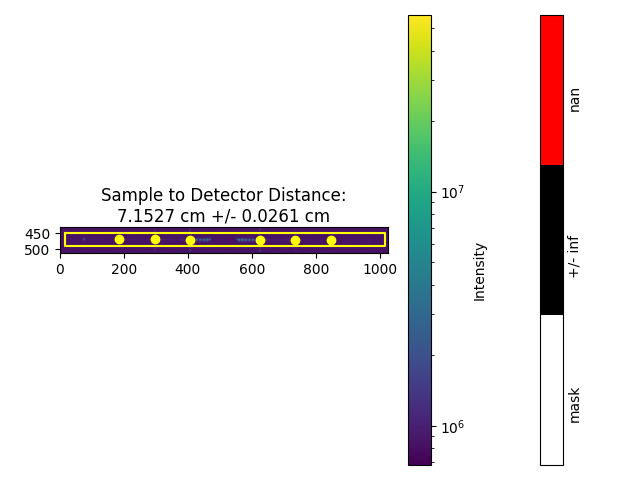

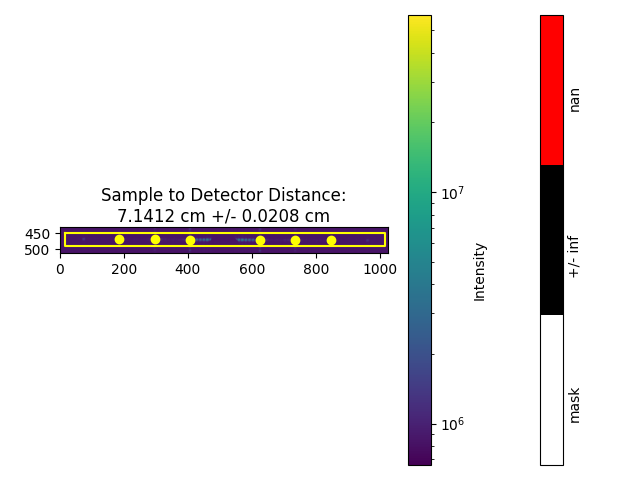

In [20]:
%matplotlib ipympl
plt.close('all')
phis = []
sdds = []

for key in data_keys:
    data = dataset.datas[key]
    sdd, sdd_std, fig = data.find_sdd_from_reference_peaks(100, 40, 1000, threshold_abs=4, min_distance=100, refinement_size=20)
    phis.append(data.metadata['sample_phi_deg'])
    sdds.append(sdd)

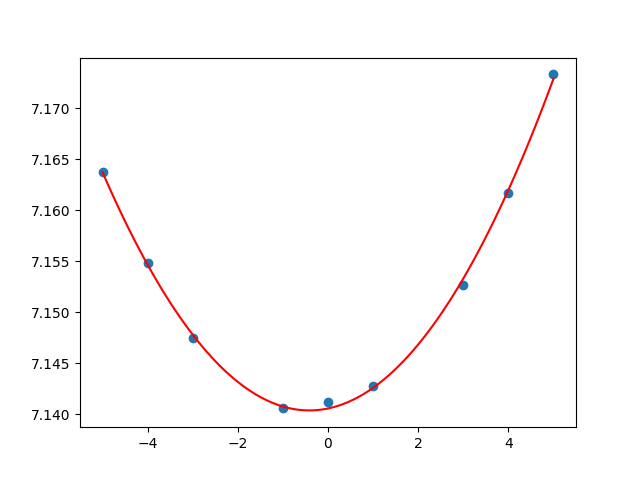

In [21]:
plt.close('all')
plt.scatter(phis, sdds)

degree = 2
coeff = np.polyfit(phis, sdds, degree)
x_new = np.linspace(np.min(phis), np.max(phis), 100)
y_new = np.polyval(coeff, x_new)

plt.plot(x_new, y_new, color='red')

In [22]:
min_phi = -1*coeff[1]/(2*coeff[0])
min_phi

np.float64(-0.41306735160866564)

In [23]:
sdd = np.polyval(coeff, min_phi)
sdd

np.float64(7.140393477350437)

In [24]:
dataset.update_all_metadata({'sample_phi_offset_deg': -1*min_phi, 'sdd_cm': sdd}) 
# data.update_metadata({'sample_phi_offset_deg': 0.413, 'sdd_cm': 7.14}) 

Updating datas:   0%|                                  | 0/312 [00:00<?, ?it/s]C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\metadata.py:89: UserWarning: No data type known for center_px_detector.
  warnings.warn(
Updating datas: 100%|████████████████████████| 312/312 [00:48<00:00,  6.43it/s]


## Chi

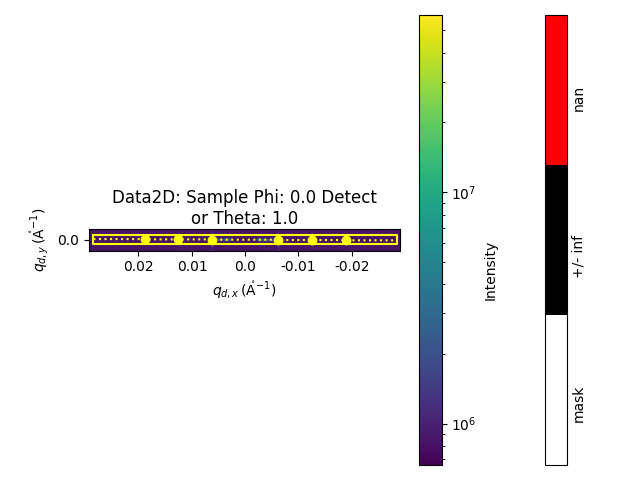

In [26]:
data = dataset.datas["Sample Phi: 0.0 Detector Theta: 1.0"]
chi, fig = data.find_chi_from_peaks(30, 1000, threshold_abs=4, min_distance=100, refinement_size=20)

In [27]:
chi

np.float64(0.26080773330752716)

In [28]:
dataset.update_all_metadata({'sample_chi_deg': chi})
# dataset.update_all_metadata({'sample_chi_deg': 0.26})

Updating datas: 100%|████████████████████████| 312/312 [00:08<00:00, 38.31it/s]


## Omega

Omega was determined to be close to zero and so sample_omega_deg is left at 0.

In [29]:
# data_keys = [key for key, value in dataset.datas.items() if np.abs(value.metadata['sample_phi_deg']) in [10, 20, 30, 40, 50] and value.metadata['detector_phi_deg'] == 1]
# data_keys

In [30]:
# %matplotlib ipympl
# plt.close('all')
# omegas = []
# phis = []

# for key in data_keys:
#     data = dataset.datas[key]
#     omega, fig = data.find_omega_from_peaks(30, 1000, threshold_abs=4, min_distance=50, refinement_size=20)
#     phis.append(data.metadata["sample_phi_deg"])
#     omegas.append(omega)

In [31]:
# plt.close('all')
# plt.figure()
# plt.errorbar(phis, omegas, fmt='o')

In [32]:
# np.average(omegas), np.std(omegas)

In [33]:
# close to zero so leaving the omega set to 0 for this set
# dataset.update_all_metadata({'sample_omega_deg': 0.0})

## Image Rotation Correction

This correction is currently using qsy to determine the angle of rotation.

In [34]:
dataset.apply_rotation_correction_all_data(use_qsy=True)#, keys=["Sample Phi: -1.0 Detector Theta: 1.0"])

Rotating datas: 100%|████████████████████████| 312/312 [01:13<00:00,  4.24it/s]


## Integrated Slices

This integration step is more complicated than you probably need. We had divided the data up into different sections and only took specific slices from each of the batches. This may not apply to you but does show how you can filter out your integration range with q.

In [38]:
plt.close('all')
int_slices = []
for data in dataset.datas.values():
    print(data.name)
    if data.metadata["detector_phi_deg"]>16.5 and data.metadata["detector_phi_deg"]<20 and data.metadata["sample_phi_deg"] > 17.5 and data.metadata["sample_phi_deg"] < 21.5:
        sat_mask = np.zeros_like(data.image).astype(float)
        sat_mask[440:500, 920:] = 1
        sat_mask = sat_mask.astype(bool)
        data.reset_mask()
        data.mask_points(sat_mask)
    int_slice0, figs = data.integrate_box(width_qdy_px=18, center_qdy=('qsy', 0), range_qdx_px=(0, 1024), show_plot=False, shift_box_qdy_px=0, subtract_background_offset=[150], plotting_kwargs=dict(color_slice='black'))
    peaks = cdsaxs.tools.find_peaks_2D_one_axis(int_slice0.image_roi, mask=int_slice0.image_mask, peak_axis=1, threshold_abs=3, min_distance=80)
    if len(peaks)>0:
        middle_y = np.average(int_slice0.limits_axis0)-1
        shift = np.round(np.average(peaks[:,0])+int_slice0.limits_axis0[0]-middle_y, 0)*-1
    else:
        shift=0
    
    # comment this part out of we want to see overlapping peaks
    q_order = 2*np.pi/1000
    image_no = int(data.metadata['filename'].split('cdsaxs')[1][6:11])
    run_no = int(data.metadata['filename'].split('cdsaxs')[1][:5])
    if run_no == 87449 and image_no >= 132:
        qsx_range = (2.5*q_order, 5.49999*q_order)
    elif run_no == 87449 and image_no < 132:
        qsx_range = (-1, 2.4999*q_order)
    elif run_no == 87450 and image_no < 57:
        qsx_range = (5.5*q_order, 9.49999*q_order)
    else:
        qsx_range = (9.499999*q_order, 1)
    range_qdx_px = (np.nanmin(np.where((int_slice0.qsx >= qsx_range[0]) & (int_slice0.qsx <= qsx_range[1]))), np.nanmax(np.where((int_slice0.qsx >= qsx_range[0]) & (int_slice0.qsx <= qsx_range[1])))+1)
    # range_qdx_px=(0, 1024)


    
    int_slice0, figs = data.integrate_box(width_qdy_px=18, center_qdy=('qsy', 0), range_qdx_px=range_qdx_px, show_plot=False, shift_box_qdy_px=int(shift), subtract_background_offset=[150], plotting_kwargs=dict(color_slice='black'))
    int_slices.append(int_slice0)



C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:1794: RuntimeWarning: Mean of empty slice
  **{key: np.nanmean(value, axis=axis)
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\data\data2d.py:1766: RuntimeWarning: Mean of empty slice
  background_i_avg = np.nanmean(
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\tools.py:492: UserWarning: Could not fit Gaussian to the peak location;assuming peak is at the pixel with the highest value.
  warnings.warn(
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\tools.py:154: UserWarning: Could not fit Gaussian to the peak location along axis 1;assuming peak is at the pixel with the highest value.
  warnings.warn(
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\tools.py:139: UserWarning: Could not fit Gaussian to

Sample Phi: -20.0 Detector Theta: 1.0
Sample Phi: 33.0 Detector Theta: 1.0
Sample Phi: -52.0 Detector Theta: 1.0
Sample Phi: 51.0 Detector Theta: 1.0
Sample Phi: -37.0 Detector Theta: 19.0
Sample Phi: 27.0 Detector Theta: 1.0
Sample Phi: 13.0 Detector Theta: 1.0
Sample Phi: -13.0 Detector Theta: 17.0
Sample Phi: 12.0 Detector Theta: 25.0
Sample Phi: 27.0 Detector Theta: 18.0
Sample Phi: 18.0 Detector Theta: 35.0
Sample Phi: -42.0 Detector Theta: 20.0
Sample Phi: 38.0 Detector Theta: 18.0
Sample Phi: 4.0 Detector Theta: 25.0


C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\tools.py:81: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


Sample Phi: 16.0 Detector Theta: 25.0
Sample Phi: 12.0 Detector Theta: 1.0
Sample Phi: -40.0 Detector Theta: 1.0
Sample Phi: -11.0 Detector Theta: 17.0
Sample Phi: 18.0 Detector Theta: 18.0
Sample Phi: -38.0 Detector Theta: 19.0
Sample Phi: 42.0 Detector Theta: 38.0
Sample Phi: 46.0 Detector Theta: 26.0
Sample Phi: -49.0 Detector Theta: 1.0
Sample Phi: -30.0 Detector Theta: 1.0
Sample Phi: -16.0 Detector Theta: 25.0
Sample Phi: 25.0 Detector Theta: 1.0
Sample Phi: 60.0 Detector Theta: 30.0
Sample Phi: -24.0 Detector Theta: 25.0
Sample Phi: 45.0 Detector Theta: 1.0
Sample Phi: 38.0 Detector Theta: 26.0
Sample Phi: 58.0 Detector Theta: 21.0
Sample Phi: -39.0 Detector Theta: 19.0
Sample Phi: -23.0 Detector Theta: 1.0
Sample Phi: -25.0 Detector Theta: 18.0
Sample Phi: -33.0 Detector Theta: 1.0
Sample Phi: -18.0 Detector Theta: 39.0
Sample Phi: 36.0 Detector Theta: 1.0
Sample Phi: 52.0 Detector Theta: 20.0
Sample Phi: -54.0 Detector Theta: 1.0
Sample Phi: 37.0 Detector Theta: 18.0
Sample Ph

C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\plotting\plotting.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\plotting\plotting.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cdsaxs\plotting\plotting.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\cmw5\Documents\beamtime_data\20251112_ALS\../../github_repos/nist_cdsaxs/src\cds

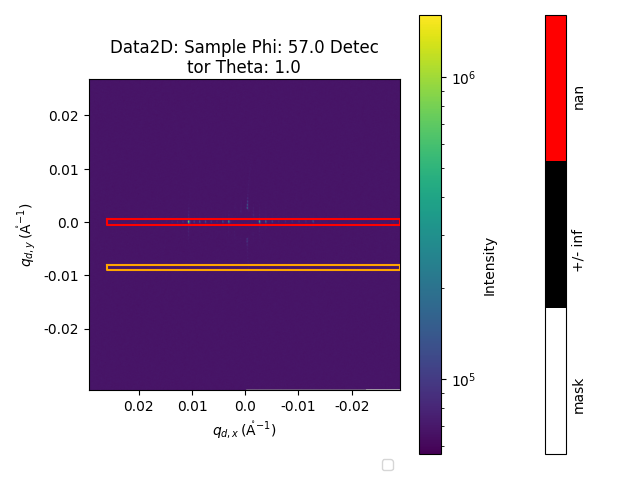

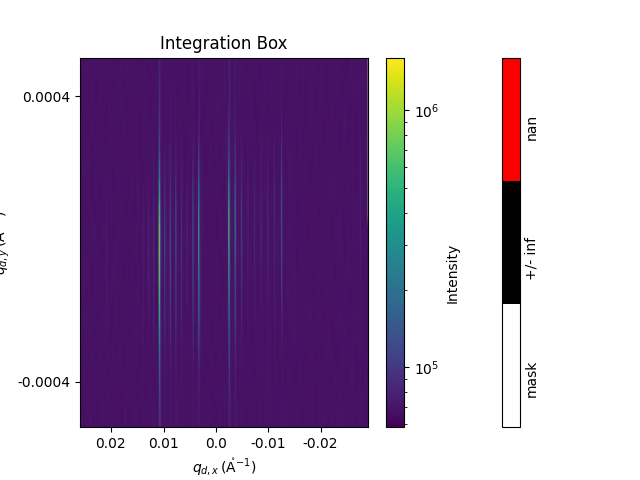

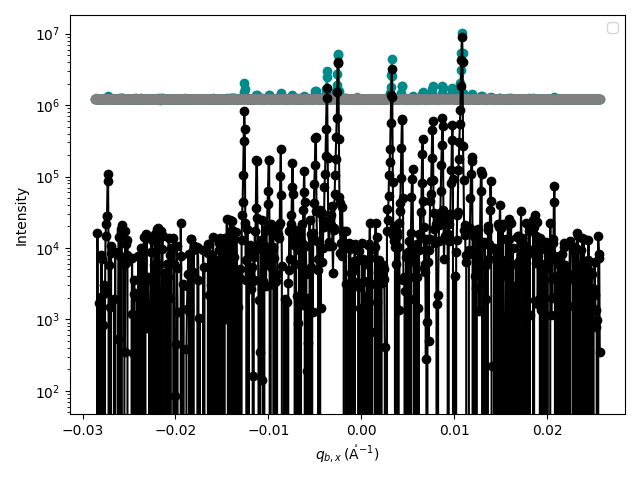

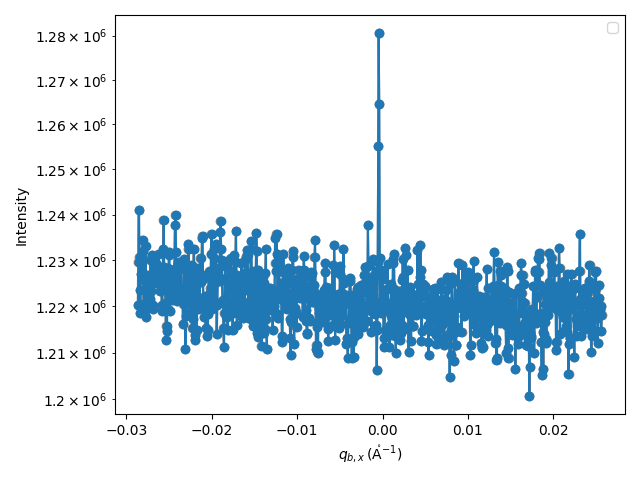

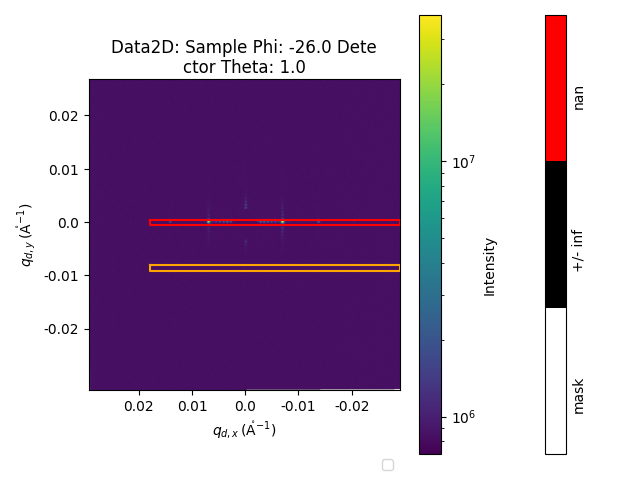

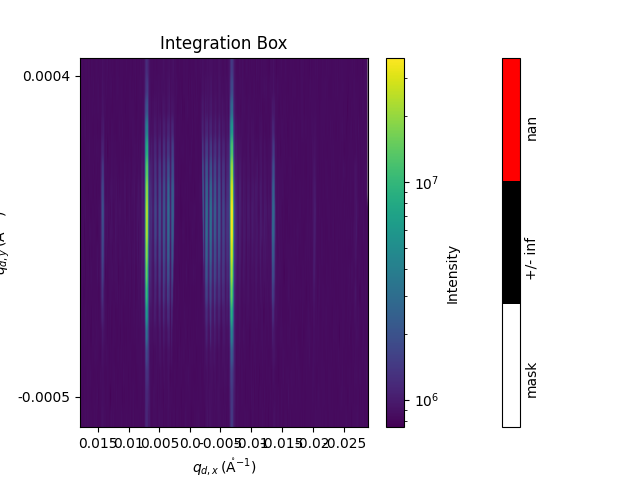

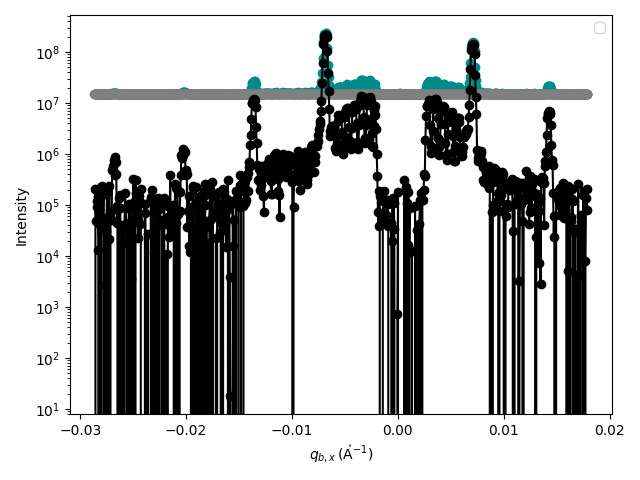

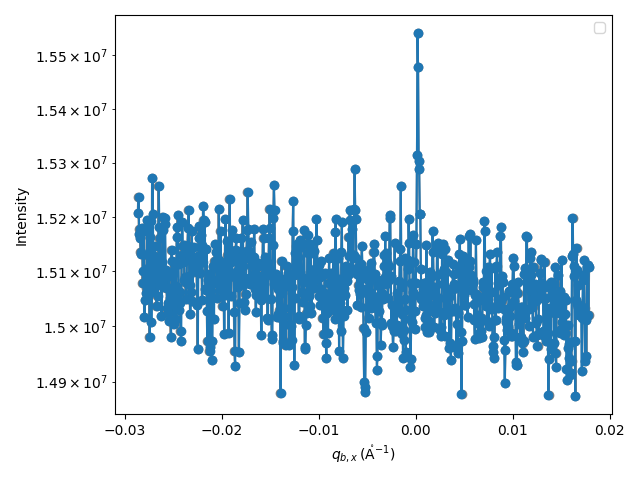

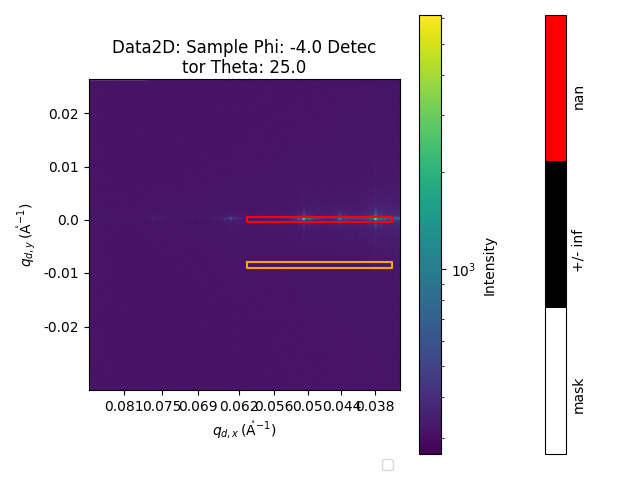

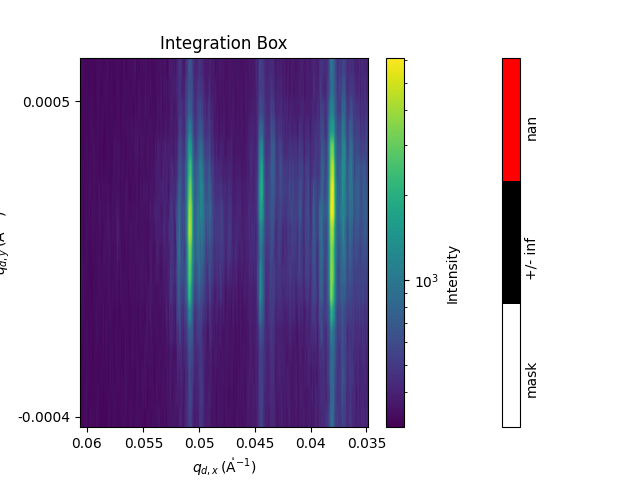

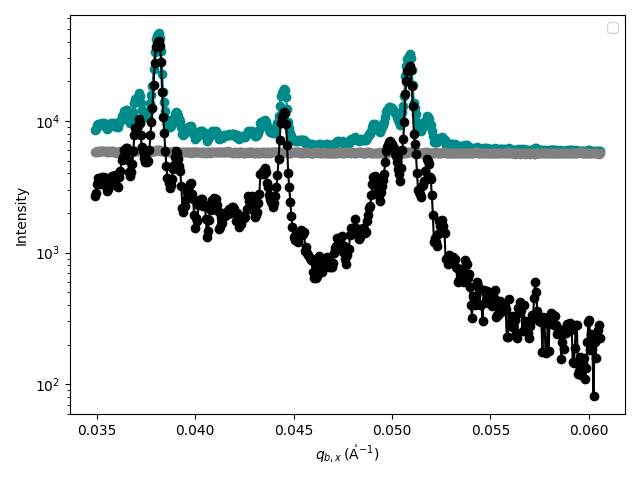

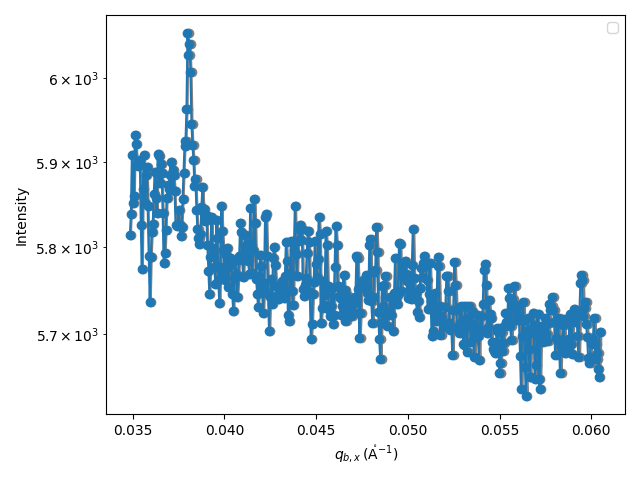

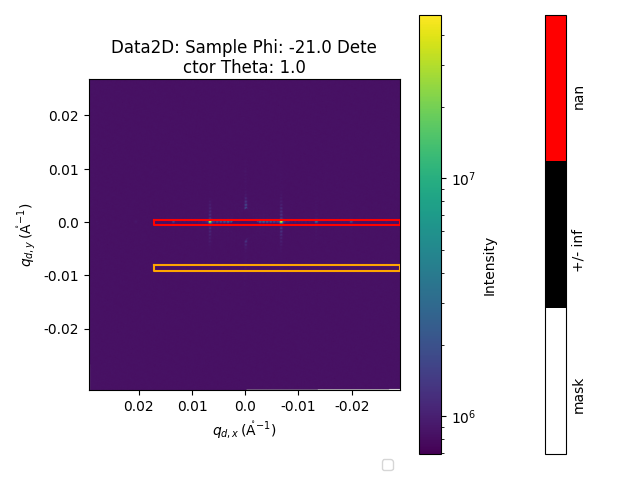

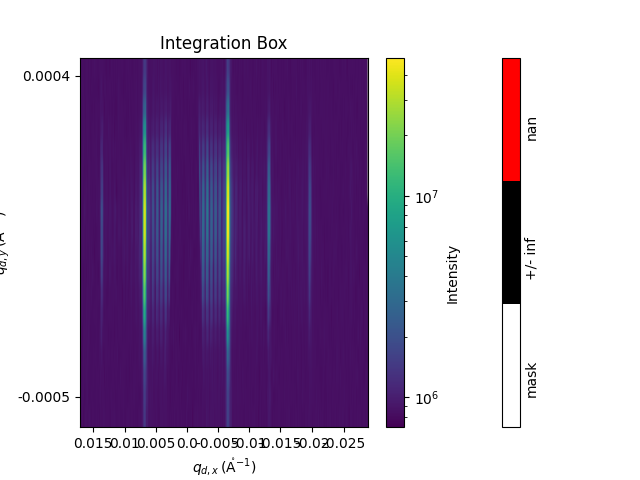

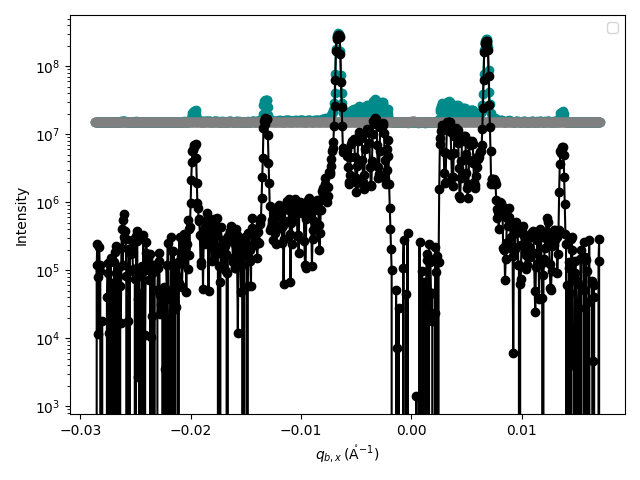

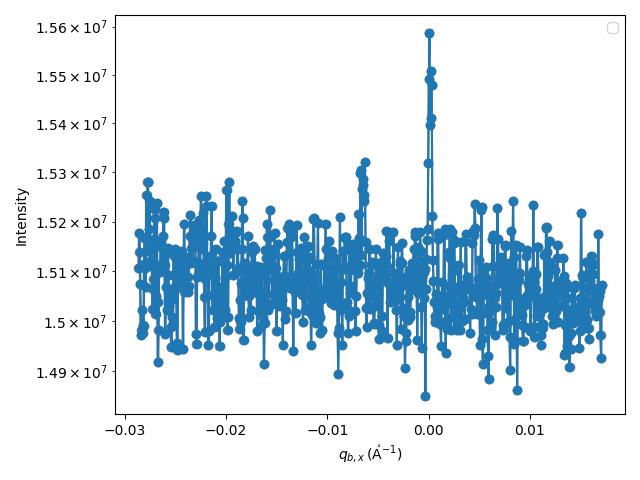

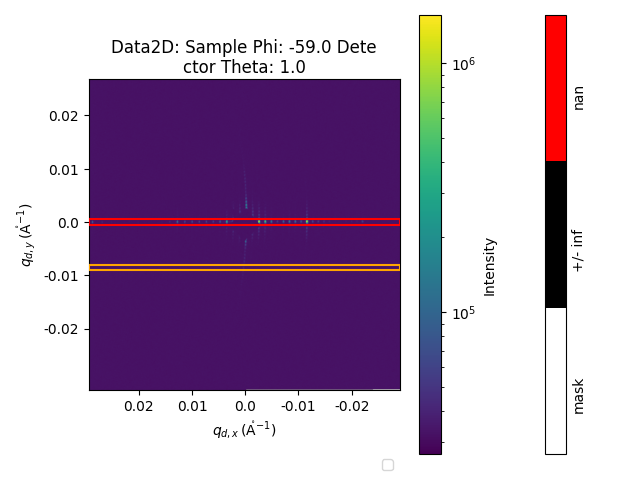

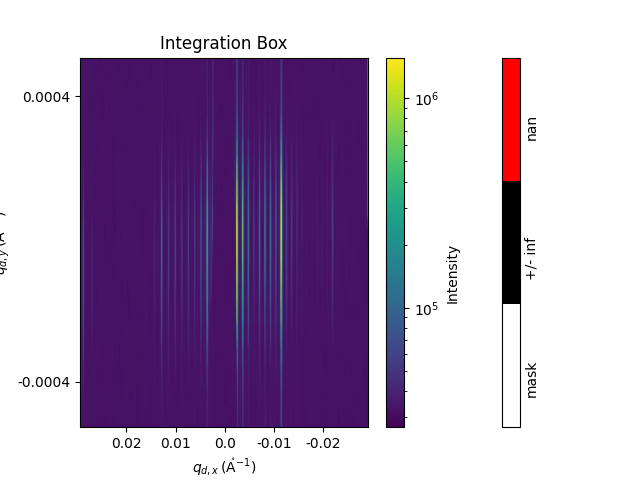

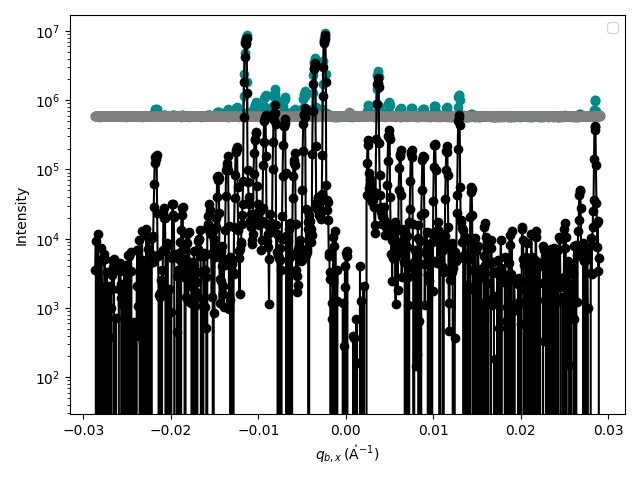

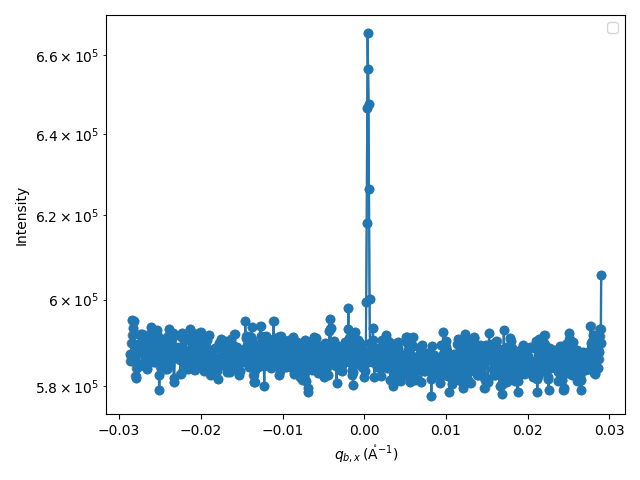

In [39]:
%matplotlib ipympl
for data in int_slices[110:115]:
    figs = cdsaxs.plotting.plotting.plot_data2d_integrate_box(data)


C:\Users\cmw5\AppData\Local\Temp\ipykernel_25812\2108049231.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


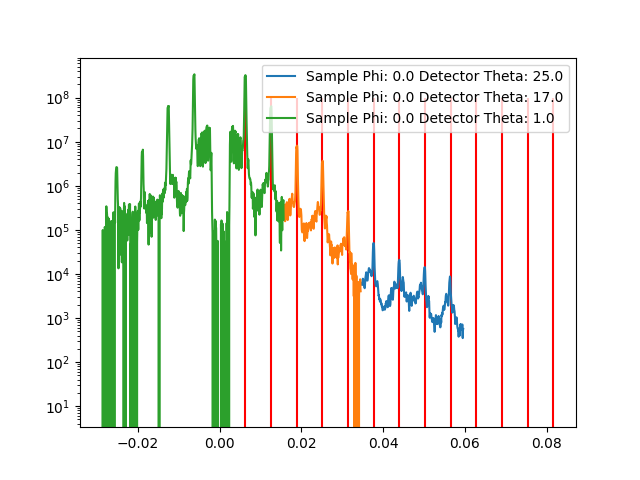

In [40]:
plt.figure()
slices = [x for x in int_slices if x.data2d.metadata["sample_phi_deg"] == 0]
# slices = [x for x in int_slices if x.data2d.metadata["sample_phi_deg"] == -34]
# data = slices[1]
# for data in int_slices:
for data in slices:
    plt.errorbar(data.q, data.Iq, label=data.data2d.name)

# # data = slices[0]
# # plt.errorbar(data.q, data.Iq, label=data.data2d.name)

# # data = slices[2]
# # plt.errorbar(data.q, data.Iq, label=data.data2d.name)

plt.yscale('log')
plt.legend(loc='upper right')

peaks = np.arange(1, 14)*2*np.pi/1000
for peak in peaks:
    plt.vlines(peak, 1, 1e8, color='red')

In [41]:
integrated_dataset = cdsaxs.data.dataset.ReducedDataset(int_slices)

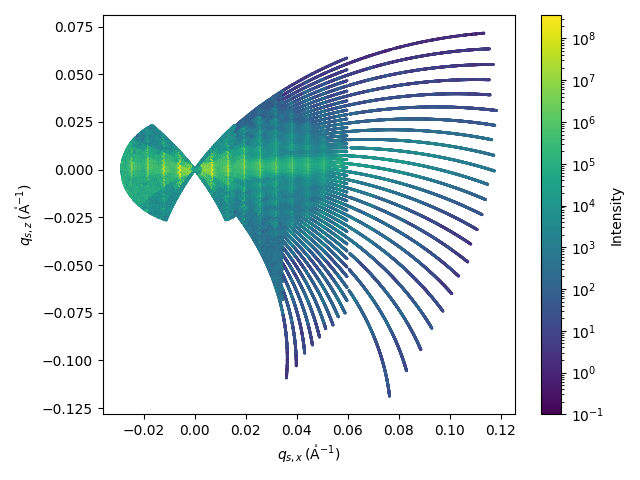

In [42]:
plt.close('all')
fig = integrated_dataset.plot_data(q_axis='qbx', s=1, )

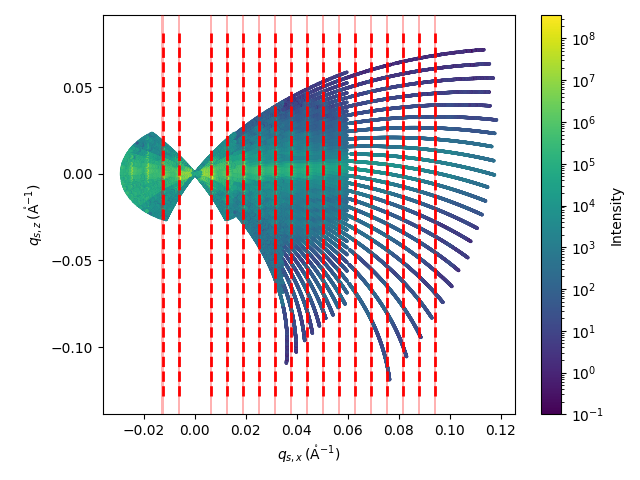

In [43]:
q_orders = np.round(np.arange(1, 16)*2*np.pi/1000, 6)
q_orders = list(np.flip(q_orders[0:2])*-1) + list(q_orders)
reduced_slices, fig = cdsaxs.reduction.slice_reduced_dataset(integrated_dataset, q_orders, q_widths=0.001, plotting_kwargs={'s': 2})

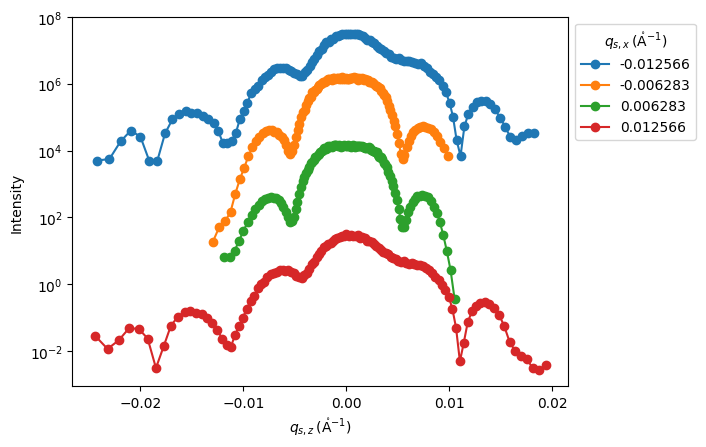

In [44]:
q_order = 2*np.pi/1000
cdsaxs.plotting.plotting.plot_reduced_slices(reduced_slices, offset_order=2, filter_by_q={'qsx':(-2.5*q_order, 2.5*q_order)})

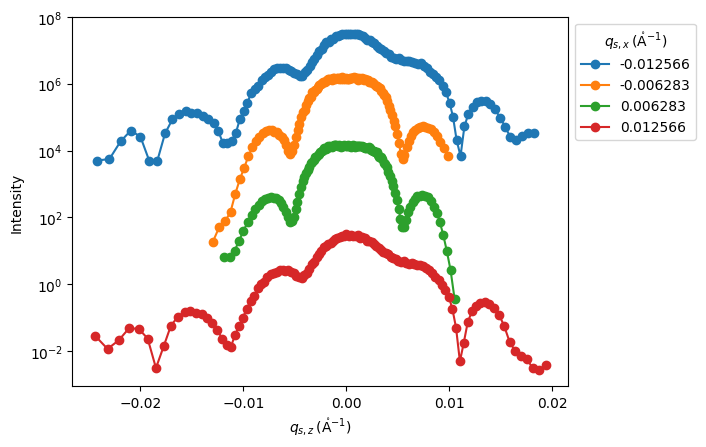

In [45]:
q_order = 2*np.pi/1000
cdsaxs.plotting.plotting.plot_reduced_slices(reduced_slices, offset_order=2, filter_by_q={'qsx':(-2.5*q_order, 2.5*q_order)})

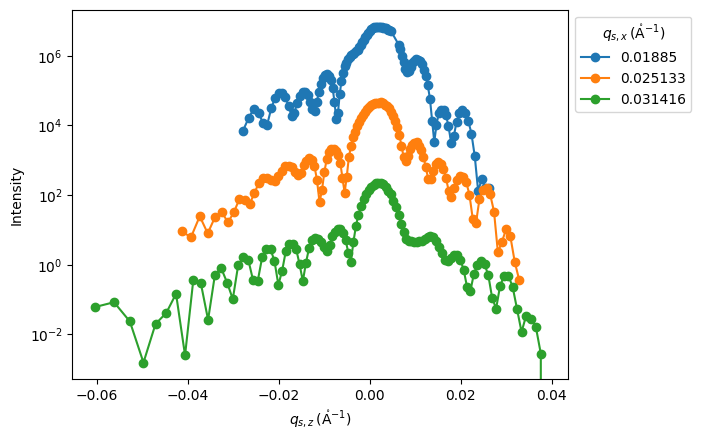

In [46]:
q_order = 2*np.pi/1000
cdsaxs.plotting.plotting.plot_reduced_slices(reduced_slices, offset_order=2, filter_by_q={'qsx':(2.5*q_order, 5.5*q_order)})

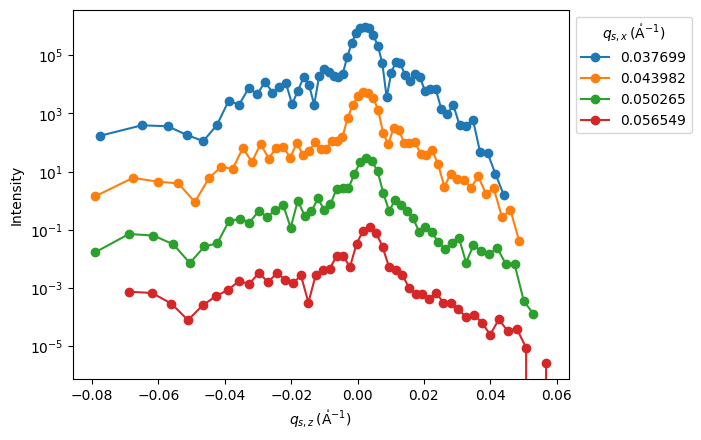

In [47]:
q_order = 2*np.pi/1000
cdsaxs.plotting.plotting.plot_reduced_slices(reduced_slices, offset_order=2, filter_by_q={'qsx':(5.5*q_order, 9.5*q_order)})

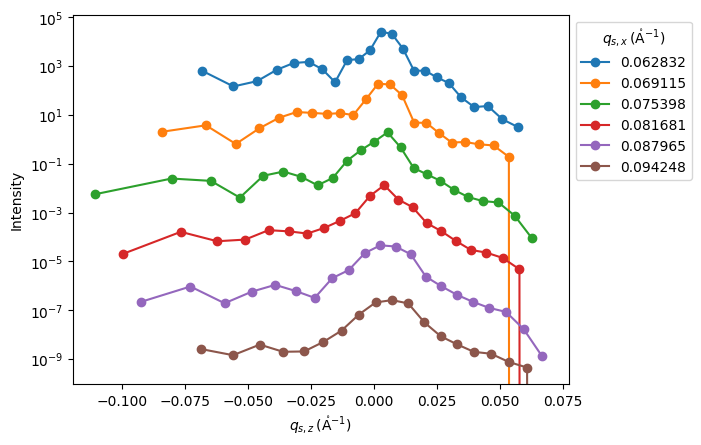

In [48]:
q_order = 2*np.pi/1000
cdsaxs.plotting.plotting.plot_reduced_slices(reduced_slices, offset_order=2, filter_by_q={'qsx':(9.5*q_order, 1)})

In [730]:
# reduced_slices.export_reduced_slices("20260304CWolf_W204_i10_slices_300ev.csv", decimals=8)

In [49]:
# reduced_slices.export_reduced_slices("20260304CWolf_W204_i10_slices_300ev_with_phi.csv", decimals=8)